# Brownlow 2025 Prediction
- Created by Jay Stein
- 3/9/22
- Purpose of this notebook is to make some awesome predictions for the upcoming Brownlow Medal
- Ensemble model

# Imports

## Standard Imports

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.mode.chained_assignment = None

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [4]:
save_file = True
model_name = 'xgboost_brownlow_simple.json'
monte_carlo_name = 'bronwlon_mc_output_v1.csv'

## Imports for XGBoost

In [5]:
# from sklearnex import patch_sklearn
# patch_sklearn()
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import xgboost as xgb
import shap

c:\Users\mrjay\miniconda3\envs\ds_std\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
from tqdm import tqdm
import random
import json
from sklearn.metrics import mean_absolute_error  # optional if you have y_true

# Read in data
- Got this using that super R library `fitzRoy`

In [6]:
#data from afl table
afltable = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\player_stats_2018_2025_fitzroy.csv", index_col=0)

C:\Users\mrjay\AppData\Local\Temp\ipykernel_16576\1989076876.py:2: DtypeWarning: Columns (50) have mixed types. Specify dtype option on import or set low_memory=False.
  afltable = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\player_stats_2018_2025_fitzroy.csv", index_col=0)


In [7]:
team_stats = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\team_stats_2018_2025_fitzroy.csv", index_col=0)

In [8]:
# read in Brownlow vote info
brownlow_votes = pd.read_csv(r"C:\Users\mrjay\python\jupyter_notebooks\Projects\brownlow\data\brownlow_stats_2018_2024_fitzroy.csv",
                             usecols=['Date','First.name','Surname','Playing.for','Brownlow.Votes'])
brownlow_votes['Date'] = pd.to_datetime(brownlow_votes['Date']).dt.date

## Data Normalization

In [9]:
def normal_cols(df):
    df.columns = df.columns.str.upper()
    df.columns = df.columns.str.replace(".","_")
    return df

In [10]:
afltable = normal_cols(afltable)
team_stats = normal_cols(team_stats)
brownlow_votes = normal_cols(brownlow_votes)

In [11]:
# get date of game
timeseries_utc = pd.to_datetime(afltable['UTCSTARTTIME'], utc=True)
local_dates = (timeseries_utc + pd.Timedelta(hours=10)).dt.date
afltable['GAME_DATE'] = local_dates

## Ensure no final rounds

In [12]:
afltable_filtered = afltable[~afltable['ROUND_NAME'].str.contains('Final')]

In [13]:
# add in full name for player
afltable_filtered['FULL_NAME'] = (afltable_filtered['PLAYER_GIVENNAME'] + ' ' + afltable_filtered['PLAYER_SURNAME']).str.upper()
brownlow_votes['FULL_NAME'] = (brownlow_votes['FIRST_NAME'] + ' ' + brownlow_votes['SURNAME']).str.upper()

In [14]:
afltable_filtered

,PROVIDERID,UTCSTARTTIME,STATUS,COMPSEASON_SHORTNAME,ROUND_NAME,ROUND_ROUNDNUMBER,VENUE_NAME,HOME_TEAM_NAME,HOME_TEAM_CLUB_NAME,AWAY_TEAM_NAME,AWAY_TEAM_CLUB_NAME,PLAYER_JUMPERNUMBER,PLAYER_PHOTOURL,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,PLAYER_PLAYER_PLAYER_CAPTAIN,PLAYER_PLAYER_PLAYER_PLAYERJUMPERNUMBER,PLAYER_PLAYER_PLAYER_GIVENNAME,PLAYER_PLAYER_PLAYER_SURNAME,TEAMID,GAMESPLAYED,TIMEONGROUNDPERCENTAGE,GOALS,BEHINDS,SUPERGOALS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,RANKING,LASTUPDATED,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,GOALEFFICIENCY,SHOTEFFICIENCY,INTERCHANGECOUNTS,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,EXTENDEDSTATS_CENTREBOUNCEATTENDANCES,EXTENDEDSTATS_KICKINS,EXTENDEDSTATS_KICKINSPLAYON,PLAYER_PLAYERID,PLAYER_CAPTAIN,PLAYER_PLAYERJUMPERNUMBER,PLAYER_GIVENNAME,PLAYER_SURNAME,TEAMSTATUS,EXTENDEDSTATS,TEAM_NAME,GAME_DATE,FULL_NAME
1,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,3,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,INT,CD_I291776,False,3,Taylor,Adams,CD_T160,NaN,54,1,0,NaN,4,4,8,3,0,0,3,6,9,2,1,0,0,0,75.0,3,0,1,32,0,1,100.0,3.4,NaN,NaN,4,0,0,1,NaN,NaN,NaN,2,106,0,1,1,3.0,75.0,1.0,6.0,2.0,0.0,33.3,0.0,0.0,0.0,3.0,1.0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD_I291776,False,3,Taylor,Adams,home,NaN,Sydney Swans,2025-03-07,TAYLOR ADAMS
2,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,36,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,FF,CD_I1008091,False,36,Joel,Amartey,CD_T160,NaN,82,3,1,NaN,7,4,11,4,0,2,5,6,11,0,1,0,1,1,72.7,0,2,0,71,0,0,75.0,11.8,NaN,NaN,1,2,1,4,NaN,NaN,NaN,5,229,0,0,0,5.0,71.4,1.8,8.0,1.0,1.0,45.5,0.0,16.7,0.0,3.0,0.0,0.0,8.0,4.0,1.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,0.0,CD_I1008091,False,36,Joel,Amartey,home,NaN,Sydney Swans,2025-03-07,JOEL AMARTEY
3,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,22,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,BPL,CD_I1006028,False,22,Nick,Blakey,CD_T160,NaN,87,1,0,NaN,21,5,26,3,4,0,6,9,15,1,0,0,0,6,80.8,4,2,0,90,13,0,100.0,22.4,NaN,NaN,4,8,0,1,NaN,NaN,NaN,3,804,0,0,0,16.0,76.2,4.2,21.0,0.0,1.0,40.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,1.0,6.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,CD_I1006028,False,22,Nick,Blakey,home,NaN,Sydney Swans,2025-03-07,NICK BLAKEY
4,CD_M20250140002,2025-03-07T08:40:00.000+0000,CONCLUDED,Premiership,Opening Round,0,SCG,Sydney Swans,Sydney Swans,Hawthorn,Hawthorn,16,https://s.afl.com.au/staticfile/AFL Tenant/AFL...,HFFL,CD_I1013133,False,16,Braeden,Campbell,CD_T160,NaN,80,0,0,NaN,6,2,8,2,0,4,2,5,7,4,0,0,0,1,87.5,0,0,0,44,1,1,0.0,9.6,NaN,NaN,2,0,0,0,NaN,NaN,NaN,3,225,0,0,0,5.0,83.3,3.0,7.0,0.0,0.0,28.6,0.0,0.0,0.0,2.0,0.0,0.0,17.0,9.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,CD_I1013133,False,16,Braeden,Campb

## Check columns with NaN

In [15]:
nan_threshold = 0.05 # set threshold at 5%
afltable_filtered_nan = afltable_filtered.isna().mean().sort_values(ascending=False).to_frame('nan_pct')
nan_cols = afltable_filtered_nan.query("nan_pct > @nan_threshold").index.tolist()
print(f"The following columns will be dropped: {nan_cols}")

The following columns will be dropped: ['SUPERGOALS', 'INTERCHANGECOUNTS', 'RANKING', 'GAMESPLAYED', 'EXTENDEDSTATS', 'GOALEFFICIENCY', 'SHOTEFFICIENCY', 'LASTUPDATED', 'EXTENDEDSTATS_KICKINS', 'EXTENDEDSTATS_KICKINSPLAYON', 'EXTENDEDSTATS_CENTREBOUNCEATTENDANCES']


In [16]:
afltable_filtered = afltable_filtered.drop(columns=nan_cols)

## Minimal feature engineering

In [17]:
afltable_filtered = afltable_filtered.assign(PLAYER_POINTS = lambda x: x['GOALS']*6 + x['BEHINDS'])

# Combine Player with Team Statistics

In [18]:
team_cols_to_keep = ['MATCHID','ROUND_YEAR','HOMETEAMSCORE_MINUTESINFRONT','AWAYTEAMSCORE_MINUTESINFRONT','HOMETEAMSCORE_MATCHSCORE_TOTALSCORE','AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE']
team_stats_subset = team_stats.loc[:,team_cols_to_keep]

In [19]:
afltable_cols_to_keep = ['PROVIDERID','ROUND_ROUNDNUMBER','HOME_TEAM_NAME','PLAYER_PLAYER_POSITION','PLAYER_PLAYER_PLAYER_PLAYERID', 'GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS',
                         'TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50','CONTESTEDMARKS','HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY',
                         'RATINGPOINTS','TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL','SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES',
                         'EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_KICKEFFICIENCY','EXTENDEDSTATS_KICKTOHANDBALLRATIO','EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS',
                         'EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE','EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE','EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS',
                         'EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS','EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES','EXTENDEDSTATS_CONTESTDEFLOSSES',
                         'EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES','EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE','TEAM_NAME','FULL_NAME','PLAYER_POINTS','PLAYER_CAPTAIN','GAME_DATE']

In [20]:
afltable_subset = afltable_filtered.loc[:,afltable_cols_to_keep]

In [21]:
merged_df = afltable_subset.merge(team_stats_subset, how='inner', left_on='PROVIDERID', right_on='MATCHID')

# add in brownlow votes
merged_df = merged_df.merge(brownlow_votes, how='left', left_on=['GAME_DATE','FULL_NAME'], right_on=['DATE','FULL_NAME'])

In [22]:
# check it is working
merged_df.query("ROUND_YEAR == 2024").groupby(['FULL_NAME'])['BROWNLOW_VOTES'].sum().sort_values(ascending=False).head(5)

FULL_NAME
PATRICK CRIPPS    45.0
NICK DAICOS       38.0
ZAK BUTTERS       29.0
ISAAC HEENEY      28.0
CALEB SERONG      28.0
Name: BROWNLOW_VOTES, dtype: float64

## More minimal feature engineering

In [23]:
merged_df = (merged_df.
             assign(AT_HOME = lambda x: (x["HOME_TEAM_NAME"] == x["TEAM_NAME"]).astype(int),
                    PLAYERTEAMSCORE = lambda x: np.where(x['AT_HOME'] == 1, x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE'], x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE']),
                    PLAYER_MINUTESINFRONT = lambda x: np.where(x['AT_HOME'] == 1, x['HOMETEAMSCORE_MINUTESINFRONT'], x['AWAYTEAMSCORE_MINUTESINFRONT']),
                    PLAYERTEAM_MARGIN = lambda x: np.where(x['AT_HOME'] == 1, 
                                                           x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE'] -  x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE'],
                                                           x['AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE'] -  x['HOMETEAMSCORE_MATCHSCORE_TOTALSCORE']
                                                           ),
                    PLAYERTEAM_OUTCOME = lambda x: np.where(
                        x['PLAYERTEAM_MARGIN'] > 0, 'WIN',
                        np.where(x['PLAYERTEAM_MARGIN'] == 0, 'DRAW','LOSE'))           
             ))

## Add in team proportions

In [24]:
proportion_features = ['GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS','TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50',
                       'CONTESTEDMARKS','HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY','RATINGPOINTS',
                       'TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL','SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES',
                       'EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE',
                       'EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE','EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS',
                       'EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS','EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES',
                       'EXTENDEDSTATS_CONTESTDEFLOSSES','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES','EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE']

In [25]:
proportion_values = merged_df.groupby(['PROVIDERID','TEAM_NAME'])[proportion_features].transform(lambda x: x/x.sum())
proportion_values = proportion_values.fillna(0) #fill in NaN

In [26]:
proportion_labels = [col + "_prop" for col in proportion_values.columns] #make some nice labels
proportion_values.columns = proportion_labels #assign new labels

In [27]:
afltable_merged = pd.concat([merged_df, proportion_values], axis=1)

In [28]:
afltable_merged.head()

,PROVIDERID,ROUND_ROUNDNUMBER,HOME_TEAM_NAME,PLAYER_PLAYER_POSITION,PLAYER_PLAYER_PLAYER_PLAYERID,GOALS,BEHINDS,KICKS,HANDBALLS,DISPOSALS,MARKS,BOUNCES,TACKLES,CONTESTEDPOSSESSIONS,UNCONTESTEDPOSSESSIONS,TOTALPOSSESSIONS,INSIDE50S,MARKSINSIDE50,CONTESTEDMARKS,HITOUTS,ONEPERCENTERS,DISPOSALEFFICIENCY,CLANGERS,FREESFOR,FREESAGAINST,DREAMTEAMPOINTS,REBOUND50S,GOALASSISTS,GOALACCURACY,RATINGPOINTS,TURNOVERS,INTERCEPTS,TACKLESINSIDE50,SHOTSATGOAL,SCOREINVOLVEMENTS,METRESGAINED,CLEARANCES_CENTRECLEARANCES,CLEARANCES_STOPPAGECLEARANCES,CLEARANCES_TOTALCLEARANCES,EXTENDEDSTATS_EFFECTIVEKICKS,EXTENDEDSTATS_KICKEFFICIENCY,EXTENDEDSTATS_KICKTOHANDBALLRATIO,EXTENDEDSTATS_EFFECTIVEDISPOSALS,EXTENDEDSTATS_MARKSONLEAD,EXTENDEDSTATS_INTERCEPTMARKS,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE,EXTENDEDSTATS_HITOUTSTOADVANTAGE,EXTENDEDSTATS_HITOUTWINPERCENTAGE,EXTENDEDSTATS_HITOUTTOADVANTAGERATE,EXTENDEDSTATS_GROUNDBALLGETS,EXTENDEDSTATS_F50GROUNDBALLGETS,EXTENDEDSTATS_SCORELAUNCHES,EXTENDEDSTATS_PRESSUREACTS,EXTENDEDSTATS_DEFHALFPRESSUREACTS,EXTENDEDSTATS_SPOILS,EXTENDEDSTATS_RUCKCONTESTS,EXTENDEDSTATS_CONTESTDEFONEONONES,EXTENDEDSTATS_CONTESTDEFLOSSES,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE,EXTENDEDSTATS_CONTESTOFFONEONONES,EXTENDEDSTATS_CONTESTOFFWINS,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE,TEAM_NAME,FULL_NAME,PLAYER_POINTS,PLAYER_CAPTAIN,GAME_DATE,MATCHID,ROUND_YEAR,HOMETEAMSCORE_MINUTESINFRONT,AWAYTEAMSCORE_MINUTESINFRONT,HOMETEAMSCORE_MATCHSCORE_TOTALSCORE,AWAYTEAMSCORE_MATCHSCORE_TOTALSCORE,DATE,FIRST_NAME,SURNAME,PLAYING_FOR,BROWNLOW_VOTES,AT_HOME,PLAYERTEAMSCORE,PLAYER_MINUTESINFRONT,PLAYERTEAM_MARGIN,PLAYERTEAM_OUTCOME,GOALS_prop,BEHINDS_prop,KICKS_prop,HANDBALLS_prop,DISPOSALS_prop,MARKS_prop,BOUNCES_prop,TACKLES_prop,CONTESTEDPOSSESSIONS_prop,UNCONTESTEDPOSSESSIONS_prop,TOTALPOSSESSIONS_prop,INSIDE50S_prop,MARKSINSIDE50_prop,CONTESTEDMARKS_prop,HITOUTS_prop,ONEPERCENTERS_prop,DISPOSALEFFICIENCY_prop,CLANGERS_prop,FREESFOR_prop,FREESAGAINST_prop,DREAMTEAMPOINTS_prop,REBOUND50S_prop,GOALASSISTS_prop,GOALACCURACY_prop,RATINGPOINTS_prop,TURNOVERS_prop,INTERCEPTS_prop,TACKLESINSIDE50_prop,SHOTSATGOAL_prop,SCOREINVOLVEMENTS_prop,METRESGAINED_prop,CLEARANCES_CENTRECLEARANCES_prop,CLEARANCES_STOPPAGECLEARANCES_prop,CLEARANCES_TOTALCLEARANCES_prop,EXTENDEDSTATS_EFFECTIVEKICKS_prop,EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop,EXTENDEDSTATS_MARKSONLEAD_prop,EXTENDEDSTATS_INTERCEPTMARKS_prop,EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop,EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop,EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop,EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop,EXTENDEDSTATS_GROUNDBALLGETS_prop,EXTENDEDSTATS_F50GROUNDBALLGETS_prop,EXTENDEDSTATS_SCORELAUNCHES_prop,EXTENDEDSTATS_PRESSUREACTS_prop,EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop,EXTENDEDSTATS_SPOILS_prop,EXTENDEDSTATS_RUCKCONTESTS_prop,EXTENDEDSTATS_CONTESTDEFONEONONES_prop,EXTENDEDSTATS_CONTESTDEFLOSSES_prop,EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop,EXTENDEDSTATS_CONTESTOFFONEONONES_prop,EXTENDEDSTATS_CONTESTOFFWINS_prop,EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop
0,CD_M20250140002,0,Sydney Swans,INT,CD_I291776,1,0,4,4,8,3,0,0,3,6,9,2,1,0,0,0,75.0,3,0,1,32,0,1,100.0,3.4,4,0,0,1,2,106,0,1,1,3.0,75.0,1.0,6.0,2.0,0.0,33.3,0.0,0.0,0.0,3.0,1.0,0.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sydney Swans,TAYLOR ADAMS,6,False,2025-03-07,CD_M20250140002,2025,15,112,76,96,NaN,NaN,NaN,NaN,NaN,1,76,15,-20,LOSE,0.090909,0.000000,0.019704,0.033898,0.024922,0.042254,0.000000,0.000000,0.024793,0.033333,0.029900,0.050,0.2,0.0,0.00000,0.000000,0.044757,0.050000,0.000000,0.043478,0.023881,0.000000,0.142857,0.16,0.019058,0.064516,0.000000,0.0,0.05,0.023529,0.019283,0.0,0.047619,0.030303,0.022222,0.025641,0.285714,0.000000,0.035516,0.0,0.000000,0.0,0.034884,0.083333,0.000000,0.026022,0.006494,0.000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
1,CD_M20250140002,0,Sydney Swans,FF,CD_I1008091,3,1,7,4,11,4,0,2,5,6,11,0,1,0,1,1,72.7,0,2,0,71,0,0,75.0,11.8,1,2,1,4,5,229,0,0,0,5.0,71.4,1.8,8.0,1.0,1.0,45.5,0.0,16.7,0.0,3.0,0.0,0.0,8.0,4.0,1.0,6.0,0

In [29]:
feature_list = ['PLAYER_PLAYER_POSITION','GOALS','BEHINDS','KICKS','HANDBALLS','DISPOSALS','MARKS','BOUNCES','TACKLES','CONTESTEDPOSSESSIONS','UNCONTESTEDPOSSESSIONS','TOTALPOSSESSIONS','INSIDE50S','MARKSINSIDE50','CONTESTEDMARKS',
                'HITOUTS','ONEPERCENTERS','DISPOSALEFFICIENCY','CLANGERS','FREESFOR','FREESAGAINST','DREAMTEAMPOINTS','REBOUND50S','GOALASSISTS','GOALACCURACY','RATINGPOINTS','TURNOVERS','INTERCEPTS','TACKLESINSIDE50','SHOTSATGOAL',
                'SCOREINVOLVEMENTS','METRESGAINED','CLEARANCES_CENTRECLEARANCES','CLEARANCES_STOPPAGECLEARANCES','CLEARANCES_TOTALCLEARANCES','EXTENDEDSTATS_EFFECTIVEKICKS','EXTENDEDSTATS_KICKEFFICIENCY','EXTENDEDSTATS_KICKTOHANDBALLRATIO',
                'EXTENDEDSTATS_EFFECTIVEDISPOSALS','EXTENDEDSTATS_MARKSONLEAD','EXTENDEDSTATS_INTERCEPTMARKS','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE','EXTENDEDSTATS_HITOUTSTOADVANTAGE','EXTENDEDSTATS_HITOUTWINPERCENTAGE',
                'EXTENDEDSTATS_HITOUTTOADVANTAGERATE','EXTENDEDSTATS_GROUNDBALLGETS','EXTENDEDSTATS_F50GROUNDBALLGETS','EXTENDEDSTATS_SCORELAUNCHES','EXTENDEDSTATS_PRESSUREACTS','EXTENDEDSTATS_DEFHALFPRESSUREACTS',
                'EXTENDEDSTATS_SPOILS','EXTENDEDSTATS_RUCKCONTESTS','EXTENDEDSTATS_CONTESTDEFONEONONES','EXTENDEDSTATS_CONTESTDEFLOSSES','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE','EXTENDEDSTATS_CONTESTOFFONEONONES',
                'EXTENDEDSTATS_CONTESTOFFWINS','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE','PLAYER_POINTS','PLAYER_CAPTAIN','AT_HOME','PLAYERTEAMSCORE','PLAYER_MINUTESINFRONT','PLAYERTEAM_MARGIN','PLAYERTEAM_OUTCOME',
                'GOALS_prop','BEHINDS_prop','KICKS_prop','HANDBALLS_prop','DISPOSALS_prop','MARKS_prop','BOUNCES_prop','TACKLES_prop','CONTESTEDPOSSESSIONS_prop','UNCONTESTEDPOSSESSIONS_prop','TOTALPOSSESSIONS_prop',
                'INSIDE50S_prop','MARKSINSIDE50_prop','CONTESTEDMARKS_prop','HITOUTS_prop','ONEPERCENTERS_prop','DISPOSALEFFICIENCY_prop','CLANGERS_prop','FREESFOR_prop','FREESAGAINST_prop','DREAMTEAMPOINTS_prop',
                'REBOUND50S_prop','GOALASSISTS_prop','GOALACCURACY_prop','RATINGPOINTS_prop','TURNOVERS_prop','INTERCEPTS_prop','TACKLESINSIDE50_prop','SHOTSATGOAL_prop','SCOREINVOLVEMENTS_prop','METRESGAINED_prop',
                'CLEARANCES_CENTRECLEARANCES_prop','CLEARANCES_STOPPAGECLEARANCES_prop','CLEARANCES_TOTALCLEARANCES_prop','EXTENDEDSTATS_EFFECTIVEKICKS_prop','EXTENDEDSTATS_EFFECTIVEDISPOSALS_prop','EXTENDEDSTATS_MARKSONLEAD_prop',
                'EXTENDEDSTATS_INTERCEPTMARKS_prop','EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE_prop','EXTENDEDSTATS_HITOUTSTOADVANTAGE_prop','EXTENDEDSTATS_HITOUTWINPERCENTAGE_prop','EXTENDEDSTATS_HITOUTTOADVANTAGERATE_prop',
                'EXTENDEDSTATS_GROUNDBALLGETS_prop','EXTENDEDSTATS_F50GROUNDBALLGETS_prop','EXTENDEDSTATS_SCORELAUNCHES_prop','EXTENDEDSTATS_PRESSUREACTS_prop','EXTENDEDSTATS_DEFHALFPRESSUREACTS_prop','EXTENDEDSTATS_SPOILS_prop',
                'EXTENDEDSTATS_RUCKCONTESTS_prop','EXTENDEDSTATS_CONTESTDEFONEONONES_prop','EXTENDEDSTATS_CONTESTDEFLOSSES_prop','EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE_prop','EXTENDEDSTATS_CONTESTOFFONEONONES_prop',
                'EXTENDEDSTATS_CONTESTOFFWINS_prop','EXTENDEDSTATS_CONTESTOFFWINSPERCENTAGE_prop']

In [30]:
X_afl_all = afltable_merged.reset_index(drop=True)
y_afl_all = afltable_merged['BROWNLOW_VOTES'].reset_index(drop=True) #remember nothing yet assigned for 2025 season train on 2018-2024

## Create reference tables player id and game id

In [31]:
player_id = afltable_merged[['PLAYER_PLAYER_PLAYER_PLAYERID','FULL_NAME']].drop_duplicates().reset_index(drop=True) #retain for reference
player_id = player_id.rename(columns={'PLAYER_PLAYER_PLAYER_PLAYERID':'PLAYER_ID'})
player_id = player_id.set_index('PLAYER_ID')
player_id['PLAYER_ID'] = player_id.index

In [32]:
game_id_df = afltable_merged[['ROUND_YEAR','ROUND_ROUNDNUMBER','MATCHID']].drop_duplicates()
game_id_df = game_id_df.reset_index(drop=True)
game_id_df['GAME_ID'] = game_id_df.index

# Use all training data

In [33]:
X_afl_train = X_afl_all.query("ROUND_YEAR != 2025")
X_afl_test = X_afl_all.query("ROUND_YEAR == 2025")
y_afl_train = y_afl_all.loc[X_afl_train.index]

In [34]:
len(X_afl_train)

61462

In [35]:
len(y_afl_train)

61462

# Check if we have all the BROWNLOW VOTES
- for previous years

In [36]:
brownlow_total_check = afltable_merged.groupby(['FULL_NAME','TEAM_NAME','ROUND_YEAR'])['BROWNLOW_VOTES'].sum().unstack(['ROUND_YEAR'])

In [37]:
brownlow_total_check

ROUND_YEAR                       2018  2019  2020  2021  2022  2023  2024  2025
FULL_NAME     TEAM_NAME                                                        
AARON BLACK   Geelong Cats        0.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
              West Coast Eagles   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN
AARON CADMAN  GWS GIANTS          NaN   NaN   NaN   NaN   NaN   0.0   0.0   0.0
AARON FRANCIS Essendon            0.0   0.0   0.0   0.0   0.0   NaN   NaN   NaN
              Sydney Swans        NaN   NaN   NaN   NaN   NaN   0.0   0.0   0.0
...                               ...   ...   ...   ...   ...   ...   ...   ...
ZAK JOHNSON   Essendon            NaN   NaN   NaN   NaN   NaN   NaN   NaN   0.0
ZAK JONES     St Kilda            NaN   NaN   7.0   4.0   0.0   0.0   1.0   0.0
              Sydney Swans        0.0   0.0   NaN   NaN   NaN   NaN   NaN   NaN
ZANE DUURSMA  North Melbourne     NaN   NaN   NaN   NaN   NaN   NaN   0.0   0.0
ZANE TREW     West Coast Eagles   NaN   NaN   NaN   NaN   0.0   0.0   0.0   NaN

[1594 rows x 8 columns]

In [38]:
years = [int(y) for y in range(2018, 2025)]
rows = []

for yr in years:
    s = brownlow_total_check[yr].nlargest(5)  # Series: index -> value, ignores NaN
    idxs = list(s.index)
    vals = list(s.values)
    # pad to length 5
    while len(idxs) < 5:
        idxs.append(pd.NA)
        vals.append(pd.NA)
    rows.append({
        'year': yr,
        'top1_name': idxs[0], 'top1_value': vals[0],
        'top2_name': idxs[1], 'top2_value': vals[1],
        'top3_name': idxs[2], 'top3_value': vals[2],
        'top4_name': idxs[3], 'top4_value': vals[3],
        'top5_name': idxs[4], 'top5_value': vals[4],
    })

top5_df = pd.DataFrame(rows).set_index('year')

In [39]:
top5_df

,top1_name,top1_value,top2_name,top2_value,top3_name,top3_value,top4_name,top4_value,top5_name,top5_value
year,,,,,,,,,,
2018,"(TOM MITCHELL, Hawthorn)",28.0,"(STEELE SIDEBOTTOM, Collingwood)",24.0,"(ANGUS BRAYSHAW, Melbourne)",21.0,"(MAX GAWN, Melbourne)",20.0,"(PATRICK CRIPPS, Carlton)",20.0
2019,"(NAT FYFE, Fremantle)",33.0,"(PATRICK DANGERFIELD, Geelong Cats)",27.0,"(LACHIE NEALE, Brisbane Lions)",26.0,"(PATRICK CRIPPS, Carlton)",26.0,"(TIM KELLY, Geelong Cats)",24.0
2020,"(LACHIE NEALE, Brisbane Lions)",31.0,"(TRAVIS BOAK, Port Adelaide)",21.0,"(CHRISTIAN PETRACCA, Melbourne)",20.0,"(JACK STEELE, St Kilda)",20.0,"(DUSTIN MARTIN, Richmond)",15.0
2021,"(OLLIE WINES, Port Adelaide)",36.0,"(MARCUS BONTEMPELLI, Western Bulldogs)",33.0,"(CLAYTON OLIVER, Melbourne)",31.0,"(SAM WALSH, Carlton)",30.0,"(DARCY PARISH, Essendon)",26.0
2022,"(PATRICK CRIPPS, Carlton)",29.0,"(LACHIE NEALE, Brisbane Lions)",28.0,"(TOUK MILLER, Gold Coast SUNS)",27.0,"(ANDREW BRAYSHAW, Fremantle)",25.0,"(CLAYTON OLIVER, Melbourne)",25.0
2023,"(LACHIE NEALE, Brisbane Lions)",31.0,"(MARCUS BONTEMPELLI, Western Bulldogs)",29.0,"(NICK DAICOS, Collingwood)",28.0,"(ERROL GULDEN, Sydney Swans)",27.0,"(ZAK BUTTERS, Port Adelaide)",27.0
2024,"(PATRICK CRIPPS, Carlton)",45.0,"(NICK DAICOS, Collingwood)",38.0,"(ZAK BUTTERS, Port Adelaide)",29.0,"(CALEB SERONG, Fremantle)",28.0,"(ISAAC HEENEY, Sydney Swans)",28.0


# Prepare for ML

In [40]:
# map the categorical cols
cat_cols = ['PLAYER_PLAYER_POSITION', 'PLAYERTEAM_OUTCOME']

In [41]:
for c in cat_cols:
    X_afl_train[c] = X_afl_train[c].astype('category')
    X_afl_test[c] = X_afl_test[c].astype('category')

In [42]:
# very small number of NaN..... we can just fill them with mean
X_afl_train[feature_list].isna().sum().sort_values(ascending=False)

EXTENDEDSTATS_KICKEFFICIENCY                   5
EXTENDEDSTATS_CONTESTDEFLOSSES                 5
EXTENDEDSTATS_RUCKCONTESTS                     5
EXTENDEDSTATS_SPOILS                           5
EXTENDEDSTATS_DEFHALFPRESSUREACTS              5
EXTENDEDSTATS_PRESSUREACTS                     5
RATINGPOINTS                                   5
EXTENDEDSTATS_SCORELAUNCHES                    5
EXTENDEDSTATS_F50GROUNDBALLGETS                5
EXTENDEDSTATS_GROUNDBALLGETS                   5
EXTENDEDSTATS_HITOUTTOADVANTAGERATE            5
EXTENDEDSTATS_HITOUTWINPERCENTAGE              5
EXTENDEDSTATS_HITOUTSTOADVANTAGE               5
EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE          5
EXTENDEDSTATS_INTERCEPTMARKS                   5
EXTENDEDSTATS_MARKSONLEAD                      5
EXTENDEDSTATS_EFFECTIVEKICKS                   5
EXTENDEDSTATS_CONTESTDEFONEONONES              5
EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE         5
EXTENDEDSTATS_KICKTOHANDBALLRATIO              5
EXTENDEDSTATS_CONTES

In [43]:
X_afl_test[feature_list].isna().sum().sort_values(ascending=False)

EXTENDEDSTATS_KICKEFFICIENCY                   7
EXTENDEDSTATS_CONTESTDEFLOSSES                 7
EXTENDEDSTATS_RUCKCONTESTS                     7
EXTENDEDSTATS_SPOILS                           7
EXTENDEDSTATS_DEFHALFPRESSUREACTS              7
EXTENDEDSTATS_PRESSUREACTS                     7
RATINGPOINTS                                   7
EXTENDEDSTATS_SCORELAUNCHES                    7
EXTENDEDSTATS_F50GROUNDBALLGETS                7
EXTENDEDSTATS_GROUNDBALLGETS                   7
EXTENDEDSTATS_HITOUTTOADVANTAGERATE            7
EXTENDEDSTATS_HITOUTWINPERCENTAGE              7
EXTENDEDSTATS_HITOUTSTOADVANTAGE               7
EXTENDEDSTATS_CONTESTEDPOSSESSIONRATE          7
EXTENDEDSTATS_INTERCEPTMARKS                   7
EXTENDEDSTATS_MARKSONLEAD                      7
EXTENDEDSTATS_EFFECTIVEKICKS                   7
EXTENDEDSTATS_CONTESTDEFONEONONES              7
EXTENDEDSTATS_CONTESTDEFLOSSPERCENTAGE         7
EXTENDEDSTATS_KICKTOHANDBALLRATIO              7
EXTENDEDSTATS_CONTES

In [44]:
X_afl_train[feature_list].shape

(61462, 120)

In [45]:
numeric_features = X_afl_train[feature_list].select_dtypes(include=['number']).columns.tolist()

In [46]:
numeric_features_means = X_afl_train[numeric_features].mean()
numeric_features_test_means = X_afl_test[numeric_features].mean()

In [47]:
# fill in the NaN
X_afl_train[numeric_features] = X_afl_train[numeric_features].fillna(numeric_features_means)
X_afl_test[numeric_features] = X_afl_test[numeric_features].fillna(numeric_features_test_means)

In [48]:
X_afl_train[feature_list].isna().sum().sum()

0

In [49]:
y_afl_train.isna().sum().sum()

1879

In [50]:
# there are some null with brownlow votes - we can safely fill them with 0
y_afl_train = y_afl_train.fillna(0)

# Time for magic!

In [51]:
data_matrix = xgb.DMatrix(data=X_afl_train[feature_list], label=y_afl_train, enable_categorical=True)

In [52]:
# CV choices
nfold = 10            # choose 5 (faster). Use 10 if you want lower variance and more compute.
seed = 42
num_boost_round = 3000
early_stopping_rounds = 100

In [53]:
# baseline params (simple, conservative baseline)
params_baseline = {
    'objective': 'reg:pseudohubererror',
    'eval_metric': 'mae',
    'verbosity': 1,
    'learning_rate': 0.05,    # reasonable default for baseline
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    # no heavy regularization here — this is a baseline
}

In [ ]:
print("Running xgb.cv baseline (this can take a while)...")
cv_results = xgb.cv(
    params=params_baseline,
    dtrain=data_matrix,
    num_boost_round=num_boost_round,
    nfold=nfold,
    early_stopping_rounds=early_stopping_rounds,
    metrics='mae',
    seed=seed,
    as_pandas=True,
    stratified=False,
    verbose_eval=50
)

Running xgb.cv baseline (this can take a while)...
[0]	train-mae:0.17494+0.00085	test-mae:0.17579+0.00654
[50]	train-mae:0.10092+0.00049	test-mae:0.12071+0.00552
[100]	train-mae:0.09047+0.00049	test-mae:0.11761+0.00554
[150]	train-mae:0.08596+0.00046	test-mae:0.11832+0.00554
[197]	train-mae:0.08219+0.00051	test-mae:0.11898+0.00561


In [55]:
best_round = len(cv_results)
best_test_mae = cv_results['test-mae-mean'].min()
print(f"\nCV complete. best_round={best_round}, best test MAE={best_test_mae:.6f}")


CV complete. best_round=98, best test MAE=0.117585


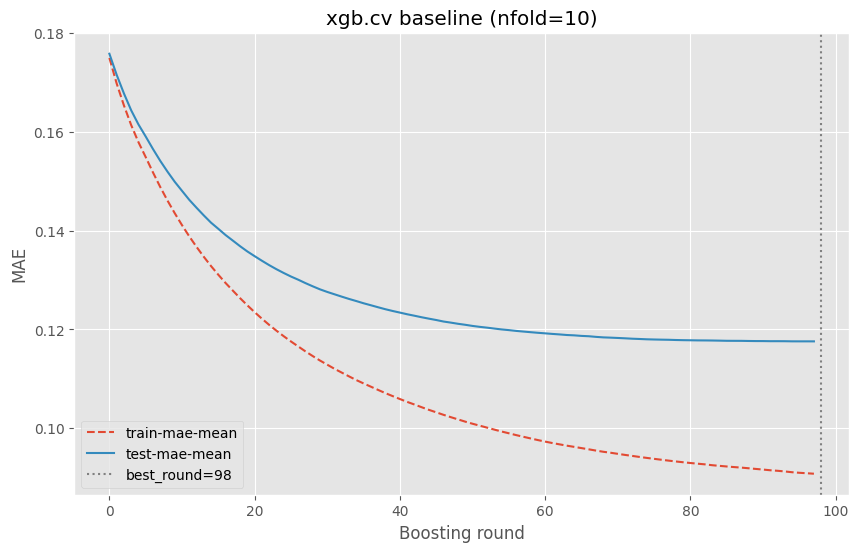

In [56]:
# Plot mean MAE curves
plt.figure(figsize=(10,6))
plt.plot(cv_results['train-mae-mean'], linestyle='--', label='train-mae-mean')
plt.plot(cv_results['test-mae-mean'], label='test-mae-mean')
plt.axvline(best_round, color='gray', linestyle=':', label=f'best_round={best_round}')
plt.xlabel('Boosting round')
plt.ylabel('MAE')
plt.title(f'xgb.cv baseline (nfold={nfold})')
plt.legend()
plt.grid(True)
plt.show()

# Ensemble time

In [64]:
# Config
n_models = 100
feature_fraction = 0.7   # fraction of features to use per model (0.5-0.9 typical)
seeds_start = 1000       # seeds will be seeds_start + i
save_models = False       # whether to save each model
model_prefix = "xgb_afl_model"

In [65]:
n_features = len(feature_list)
k_features = max(1, int(np.round(feature_fraction * n_features)))

all_preds = []          # list of arrays shape (n_rows_pred,)
model_info = []         # store metadata for each model
models = []

In [66]:
for i in tqdm(range(n_models), desc="Ensemble training"):
    seed = seeds_start + i
    # choose random feature subset (without replacement)
    feat_subset = sorted(random.sample(feature_list, k_features))

    # prepare DMatrix for this model (ensure ordering matches feat_subset)
    dtrain_i = xgb.DMatrix(X_afl_train[feat_subset], label=y_afl_train, enable_categorical=True)

    # params for this run
    params_i = dict(params_baseline)
    params_i['seed'] = seed

    # train
    bst = xgb.train(params_i, dtrain_i, num_boost_round=best_round, verbose_eval=False)
    models.append(bst)

    # predict on X_pred using only the selected features (ensure dtype consistency)
    dtest_i = xgb.DMatrix(X_afl_test[feat_subset], enable_categorical=True)
    preds_i = bst.predict(dtest_i)

    all_preds.append(preds_i)
    model_info.append({'model_index': i, 'seed': seed, 'n_features': len(feat_subset), 'features': feat_subset})

    # optionally save model and metadata
    if save_models:
        fname = f"../models/{model_prefix}_{i}.json"
        bst.save_model(fname)
        with open(f"../models/{model_prefix}_{i}_meta.json", "w") as f:
            json.dump({'seed': seed, 'features': feat_subset, 'params': params_i}, f)

# Stack predictions -> shape (n_models, n_rows)
preds_stack = np.vstack(all_preds)

# Aggregations
pred_mean = preds_stack.mean(axis=0)
pred_median = np.median(preds_stack, axis=0)
pred_std = preds_stack.std(axis=0)
pred_p05 = np.percentile(preds_stack, 5, axis=0)
pred_p95 = np.percentile(preds_stack, 95, axis=0)

# put into DataFrame
out = X_afl_test.copy().reset_index(drop=True)
out['pred_mean'] = pred_mean
out['pred_median'] = pred_median
out['pred_std'] = pred_std
out['pred_p05'] = pred_p05
out['pred_p95'] = pred_p95

# optional: if you have true labels for X_pred (y_pred_true), compute MAE
# print("Ensemble MAE:", mean_absolute_error(y_pred_true, pred_mean))

# Save ensemble predictions and model info
out.to_csv("../models/ensemble_predictions.csv", index=False)
with open("../models/ensemble_model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print("Ensemble complete. Saved ensemble_predictions.csv and ensemble_model_info.json")

Ensemble training: 100%|██████████| 100/100 [01:15<00:00,  1.33it/s]


Ensemble complete. Saved ensemble_predictions.csv and ensemble_model_info.json


# Rank and score for each game

In [ ]:
full_df_pred['BROWNLOW_RANK'] = (full_df_pred
                                 .groupby(['MATCHID'])['BROWNLOW_FLOAT_PREDICTION']
                                 .rank(method='min', ascending=False)) # the method just means a tie gets the lowest rank value like a tie for top both get a 1

In [ ]:
rank_series = full_df_pred['BROWNLOW_RANK'].astype(float)

full_df_pred['BROWNLOW_POINTS'] = np.select(
    condlist=[rank_series == 1, rank_series == 2, rank_series == 3],
    choicelist=[3,2,1],
    default=0
).astype(int)

In [ ]:
# monte carlo output
mc_output_cols = ['FULL_NAME','TEAM_NAME','ROUND_ROUNDNUMBER','MATCHID','BROWNLOW_FLOAT_PREDICTION']

if save_file:
    full_df_pred[mc_output_cols].to_csv(f'../result/{monte_carlo_name}', index=False)

# Summary Stats

In [ ]:
votes_by_player = full_df_pred.groupby(['FULL_NAME','TEAM_NAME'])['BROWNLOW_POINTS'].sum()
votes_by_player = votes_by_player.sort_values(ascending=False).reset_index()

In [ ]:
max_votes_idx = votes_by_player.groupby('TEAM_NAME')['BROWNLOW_POINTS'].idxmax()
votes_by_team = votes_by_player.loc[max_votes_idx].reset_index(drop=True)
votes_by_team

In [ ]:
player_check = 'JACK GUNSTON'
player_check_by_round = (full_df_pred
                         .query(f"FULL_NAME == '{player_check}'")
                         .groupby(['ROUND_ROUNDNUMBER'])[['BROWNLOW_FLOAT_PREDICTION','BROWNLOW_POINTS']]
                         .sum())

display(player_check_by_round)

In [ ]:
# full_df_pred.query("MATCHID == 'CD_M20250140903'").sort_values(by='BROWNLOW_FLOAT_PREDICTION', ascending=False)